In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os
from scipy import stats
from transects import transects, plot_transects
from data import martw_query
from shapely.ops import Point, LineString

c:\Users\Budniak Piotr\met_liniowa\WislDb.py:11: SAWarning: Unrecognized server version info '17.0.1000.7'.  Some SQL Server features may not function properly.
  __table__ = Table('ADRES_POW', metadata, autoload_with=engine, resolve_fks=False)


In [2]:
os.chdir('C:/Users/Budniak Piotr/met_liniowa/wyniki_wariantow_transektow')

def oblicz(x, odl, n_trans):
    miaższosc = x.MIAZSZOSC.sum() / 400 * 10000
    len_trans = (x.PROMIEN_A.iloc[0] * n_trans - n_trans * odl) / 100
    suma_kw_srednic = ((x.D12 / 10)**2 * x.przeciecia).sum()
    miazszosc_liniowa = 1.2337 / len_trans * suma_kw_srednic

    return pd.Series({'zasobnosc': miaższosc, 'zasob_lin': miazszosc_liniowa})

result_df = pd.DataFrame()

for i in os.listdir():
    if i.endswith('.parquet'):
        try:
            odl = int(i.split('_')[-1][4:7])
        except ValueError:
            odl = 0
            
        n_trans = int(i.split('_')[1][-1])

        df = pd.read_parquet(i)
        #Dla uproszczenia wybieramy tylko powierzchnie niepodzielone
        df = df[df.NR_PODPOW.astype(str).str[-2] == '0']

        wynik_df = df.groupby('NR_PODPOW', as_index=False).apply(oblicz, odl=odl, n_trans=n_trans)

        trans_len = n_trans * 1128 - n_trans * odl

        zasob_mean =wynik_df.zasobnosc.mean()
        zasob_lin_mean = wynik_df.zasob_lin.mean()

        roznica = wynik_df['zasob_lin'] - wynik_df['zasobnosc']
        bias = roznica.mean()
        mae = roznica.abs().mean()
        rmse = np.sqrt((roznica**2).mean())
        srednia_referencyjna = wynik_df['zasobnosc'].mean()
        rmse_procent = (rmse / srednia_referencyjna) * 100
        spearman_corr, spearman_p = stats.spearmanr(wynik_df['zasobnosc'], wynik_df['zasob_lin'])

        res = pd.Series({'trans_len': trans_len, 
                   'zasob_mean': zasob_mean, 
                   'zasob_lin_mean': zasob_lin_mean, 
                   'bias': bias, 'mae': mae, 
                   'rmse': rmse, 
                   'rmse_procent': rmse_procent, 
                   'spearman_corr': spearman_corr, 
                   'spearman_p': spearman_p},
                   name = i[:-8]).to_frame()
        
        result_df = pd.concat([result_df, res], axis=1)

result_df_T = result_df.T
result_df_T['trans_len'] = result_df_T['trans_len'] / 100
result_df_T['n_trans'] = list((result_df_T.index.get_level_values(0).str[8].astype(int) ** 2) * 10)

# Wyznacz front Pareto (min rmse_procent, min trans_len)
def pareto_mask(df, c1, c2):
    pts = df[[c1, c2]].values
    is_pareto = np.ones(len(pts), dtype=bool)
    for i in range(len(pts)):
        for j in range(len(pts)):
            if i != j:
                if pts[j,0] <= pts[i,0] and pts[j,1] <= pts[i,1] and (pts[j,0] < pts[i,0] or pts[j,1] < pts[i,1]):
                    is_pareto[i] = False
                    break
    return is_pareto

pareto_mask = pareto_mask(result_df_T, 'rmse_procent', 'trans_len')
pareto_front = result_df_T[pareto_mask]
pareto_front = pareto_front.sort_values('trans_len')
recommended = pareto_front[pareto_front.index == 'n_trans-3_angle-30_odl-0']
lokiec = pareto_front.iloc[[0,6,-1],:]

In [4]:
result_df_T

,trans_len,zasob_mean,zasob_lin_mean,bias,mae,rmse,rmse_procent,spearman_corr,spearman_p,n_trans
n_trans-2_angle-0_odl-0,22.56,12.13069,12.791301,0.660610,9.285595,23.340295,192.406978,0.603913,0.0,40
n_trans-2_angle-0_odl-100,20.56,12.13069,12.877537,0.746846,9.908824,25.108871,206.986332,0.582396,0.0,40
n_trans-2_angle-0_odl-200,18.56,12.13069,12.880716,0.750026,10.589510,27.443865,226.234981,0.558617,0.0,40
n_trans-2_angle-0_odl-300,16.56,12.13069,13.049511,0.918821,11.372600,29.972717,247.081709,0.533754,0.0,40
n_trans-2_angle-45_odl-0,22.56,12.13069,12.291295,0.160605,9.055575,21.572988,177.838085,0.611978,0.0,40
n_trans-2_angle-45_odl-100,20.56,12.13069,12.384212,0.253521,9.692882,23.069935,190.178248,0.590761,0.0,40
n_trans-2_angle-45_odl-200,18.56,12.13069,12.461462,0.330772,10.293632,24.729863,203.861960,0.571115,0.0,40
n_trans-2_angle-45_odl-300,16.56,12.13069,12.444116,0.313425,11.077765,26.995221,222.536560,0.543363,0.0,40
n_trans-2_angle-90_odl-0,22.56,12.13069,11.639374,-0.491316,8.885220,20.458563,168.651265,0.594078,0.0,40
n_trans-2_angle-90_odl-100,20.56,12.13069,11.696399,-0.434291,9.508894,21.953142,180.971904,0.574074,0.0,40


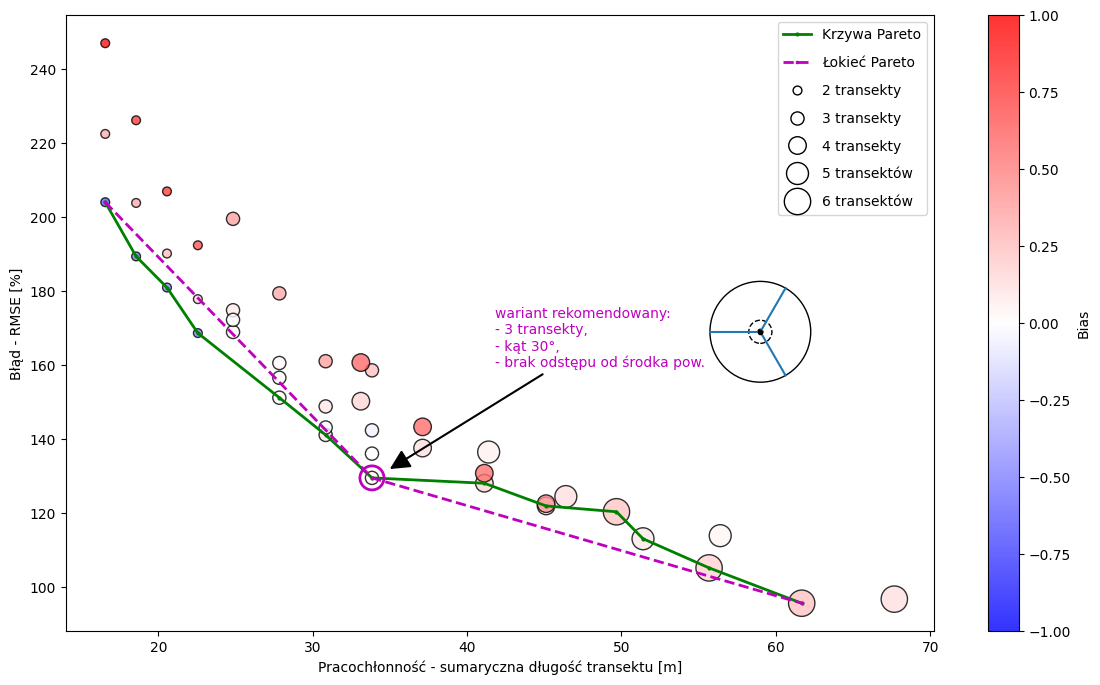

In [3]:
fig, ax = plt.subplots(figsize=(14, 8))

scatter = ax.scatter(x = 'trans_len',
            y = 'rmse_procent', 
            data = result_df_T,
            s = 'n_trans',
            c = 'bias',
            cmap="bwr",
            vmin = -1,
            vmax = 1,
            edgecolor = 'black',
            alpha = .8)

ax.scatter(recommended['trans_len'], recommended['rmse_procent'],
           s=300, 
           facecolors='none', 
           edgecolors='m', 
           linewidths=2, 
           zorder=4)

ax.annotate('wariant rekomendowany:\n- 3 transekty,\n- kąt 30°,\n- brak odstępu od środka pow.',
            xy=(recommended['trans_len'].values[0]+1, recommended['rmse_procent'].values[0]+2),
            xytext=(recommended['trans_len'].values[0] + 8, recommended['rmse_procent'].values[0] + 30),
            arrowprops=dict(arrowstyle='-|>, head_width=0.6, head_length=1.2', color='black', lw=1.5, zorder=5),
            fontsize=10, color='m', zorder=5)

ax.plot(pareto_front['trans_len'], 
        pareto_front['rmse_procent'],  
        color='green', 
        linestyle='-', 
        linewidth=2,
        marker='o',
        markersize=2,
        label='Krzywa Pareto')

ax.plot(lokiec['trans_len'],
        lokiec['rmse_procent'],
        color='m',
        linestyle='--',
        linewidth=2,
        marker='s',
        markersize=2,
        label='Łokieć Pareto')

axin = ax.inset_axes(
        [54, 154, 10, 30], transform = ax.transData)
axin.set_axis_off()
axin.set_aspect('equal')
res = (transects(num = 3, angle = 30, dist_start=0))
plot_transects(res, ax=axin)

ax.set_xlabel('Pracochłonność - sumaryczna długość transektu [m]')
ax.set_ylabel('Błąd - RMSE [%]')

plt.legend()
plt.colorbar(scatter, label='Bias');

handles, labels = ax.get_legend_handles_labels()
handles = handles[1:]
labels = labels[1:]

for i in range(2, 7):
    artist = Line2D([0], [0], marker='o', color='w', label=f'{i} transekty',
                        markerfacecolor='none', markeredgecolor='black', markersize=(i**2 * 10)**0.5)
    handles.append(artist)
    if i < 5:
        labels.append(f'{i} transekty')
    else:
        labels.append(f'{i} transektów')

ax.legend(handles, labels, labelspacing=1)


In [4]:
martwe = martw_query()
martwe = martwe.to_pandas()

def nearest_distanse_from_plot_center(x:pd.DataFrame):
    center = Point(0,0)
    line = LineString([(x['X_start'], x['Y_start']), (x['X_end'], x['Y_end'])])
    return center.distance(line)

martwe['nearest_dist_from_center'] = martwe.apply(nearest_distanse_from_plot_center, axis=1)

# Jaki procent leżaniny przebiega w odległości mnijeszej niż 25 cm od śreodka powierzchni?
print(f'procent leżaniny w liczbie sztuk, przebiegającej w odległości < 25 cm od środka powierzchni: \
      {martwe.query("nearest_dist_from_center < 25").__len__() / martwe.__len__() * 100:.2f}%')
print(f'procent leżaniny w masie, przebiegającej w odległości < 25 cm od środka powierzchni: \
      {martwe.query("nearest_dist_from_center < 25").MIAZSZOSC.sum() / martwe.MIAZSZOSC.sum() * 100:.2f}%')

C:\Users\Budniak Piotr\AppData\Local\Programs\Python\Python313\Lib\contextlib.py:141: SAWarning: Unrecognized server version info '17.0.1000.7'.  Some SQL Server features may not function properly.
  return next(self.gen)


procent leżaniny w liczbie sztuk, przebiegającej w odległości < 25 cm od środka powierzchni:       0.52%
procent leżaniny w masie, przebiegającej w odległości < 25 cm od środka powierzchni:       1.39%


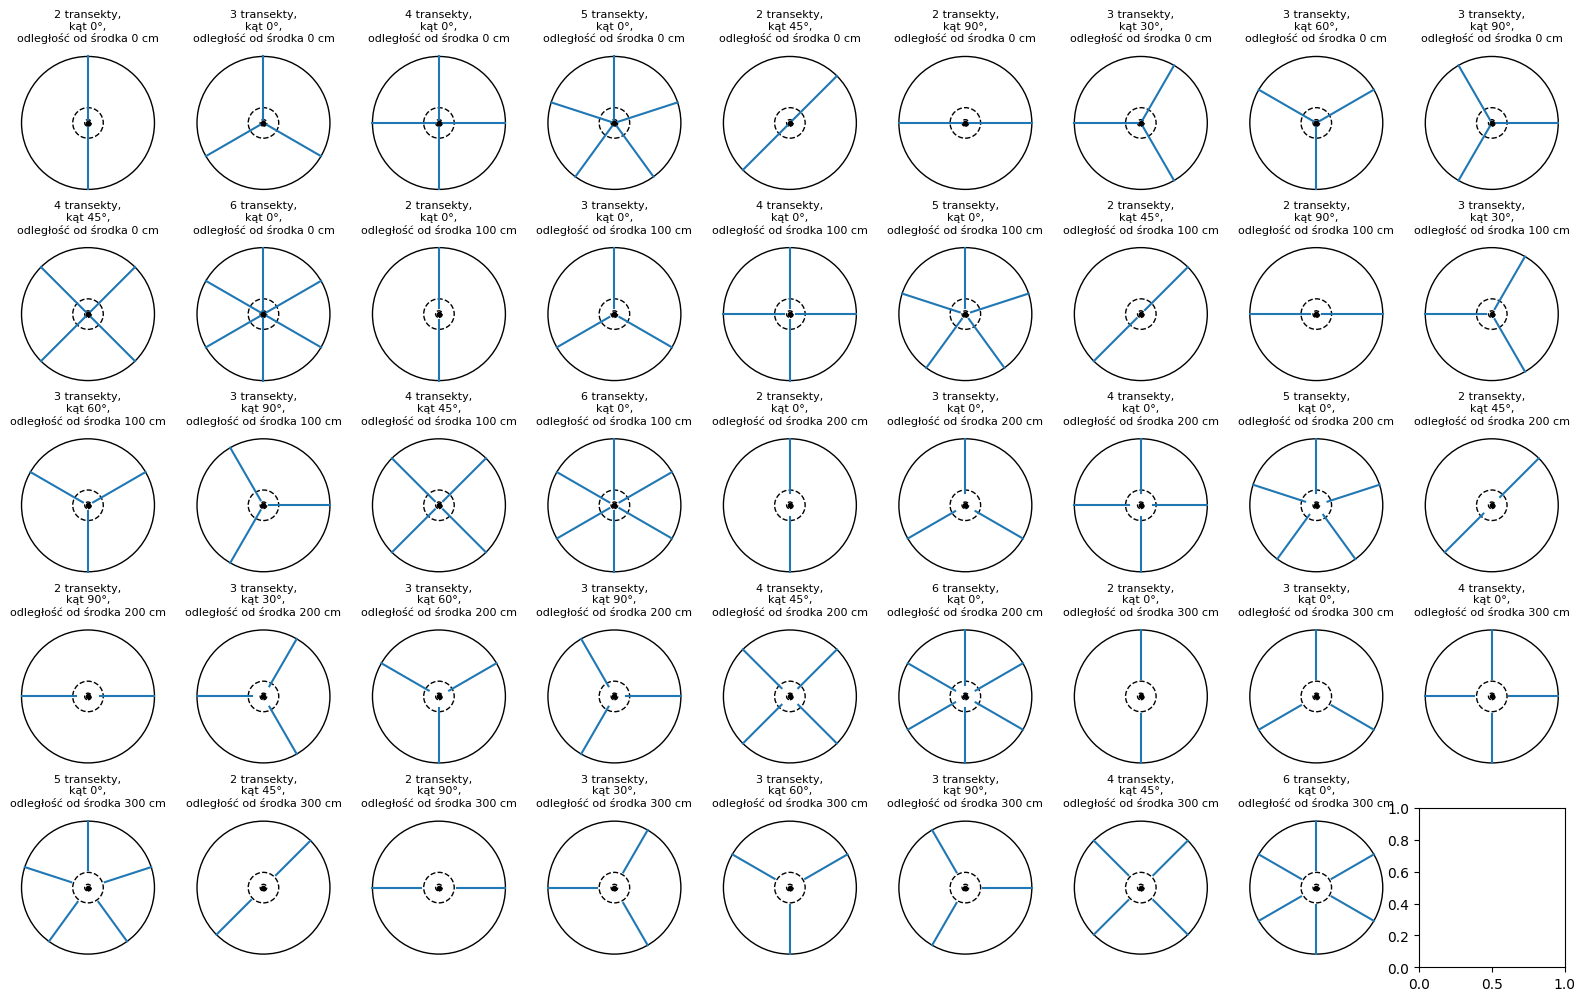

In [8]:
fig, ax = plt.subplots(5,9,figsize=(20, 12))

ax = ax.flatten()

warianty_testowe = [
    (2, 0),
    (3, 0),
    (4, 0),
    (5, 0),
    (2, 45),
    (2, 90),
    (3, 30),
    (3, 60),
    (3, 90),
    (4, 45),
    (6, 0)
]

#Testowane odległości początku transektu od środka w cm

odleglosc = [0, 100, 200, 300]

war = []

for odl in odleglosc:
    for n_trans, angle in warianty_testowe:
        war.append((n_trans, angle, odl))

for ax, war in zip(ax, war):
    res = transects(num = war[0], angle = war[1], dist_start=war[2])
    plot_transects(res, ax=ax)
    ax.set_title(f'{war[0]} transekty,\nkąt {war[1]}°,\nodległość od środka {war[2]} cm', fontsize=8)
    ax.set_axis_off()
    ax.set_aspect('equal')

Text(0.02, 0.5, 'Miąższość [m³/ha] z transektów')

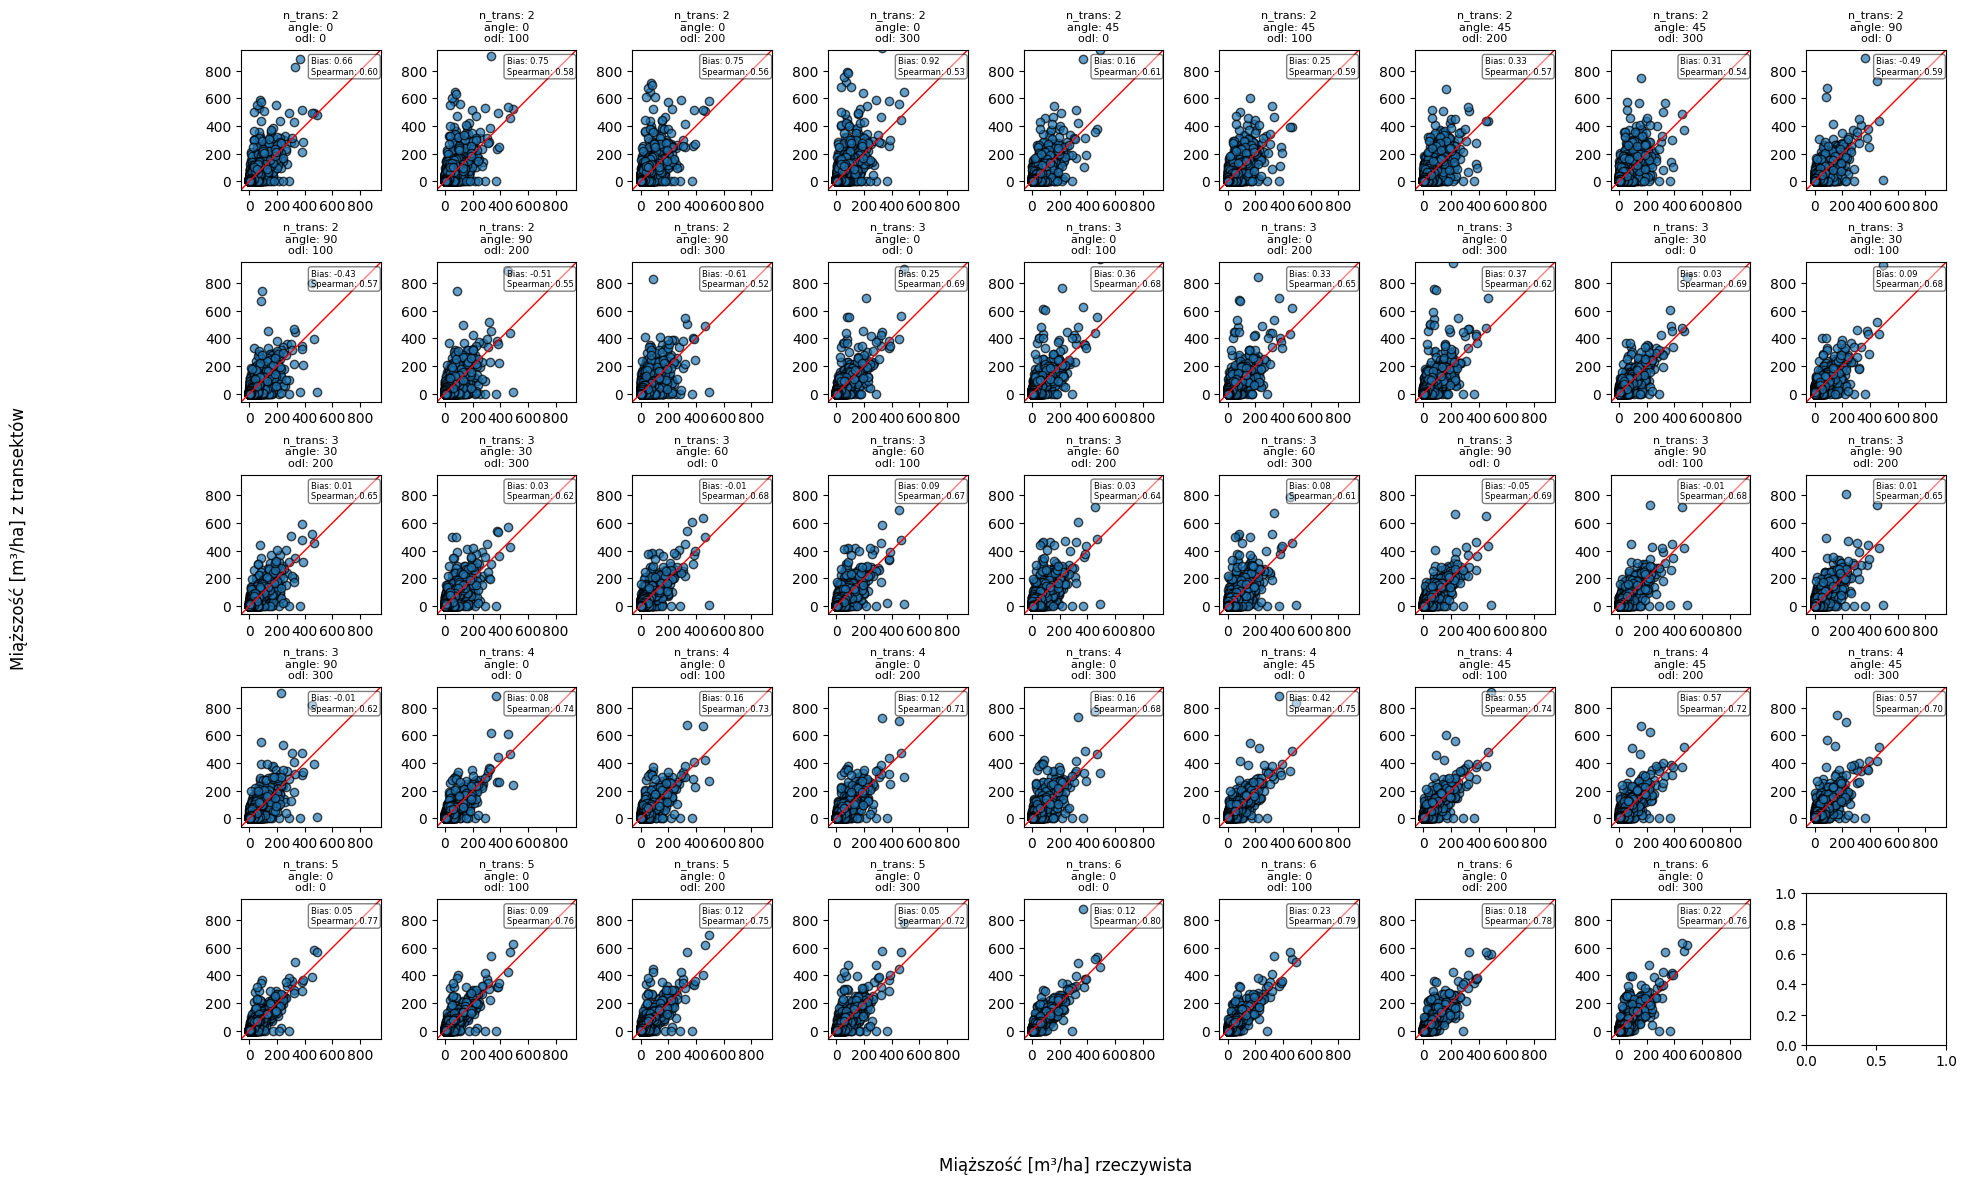

In [ ]:
fig, axes = plt.subplots(5, 9, figsize=(22, 13))
axes = axes.flatten()

for i, ax in zip(os.listdir(), axes):
    if i.endswith('.parquet'):
        try:
            odl = int(i.split('_')[-1][4:7])
        except ValueError:
            odl = 0
            
        n_trans = int(i.split('_')[1][-1])

        df = pd.read_parquet(i)
        #Dla uproszczenia wybieramy tylko powierzchnie niepodzielone
        df = df[df.NR_PODPOW.astype(str).str[-2] == '0']

        wynik_df = df.groupby('NR_PODPOW', as_index=False).apply(oblicz, odl=odl, n_trans=n_trans)
        
        ax.scatter(x = 'zasobnosc',
                   y = 'zasob_lin',
                   data=wynik_df,
                   alpha=0.7,
                   edgecolor='black',)
        
        line_xy = np.linspace(-60, 950, 10)
        ax.plot(line_xy, line_xy, color='red', linewidth=1)
        
        lim = (-60, 950)
        ticks = np.arange(0, 1000, 200)
        ax.set_xlim(lim)
        ax.set_ylim(lim)
        ax.set_xticks(ticks)
        ax.set_yticks(ticks) 
        ax.set_aspect('equal')
        ax.set_title(f'n_trans: {n_trans}\nangle: {int(i.split("_")[2][6:])}\nodl: {odl}', fontsize=8)

        zasob_mean =wynik_df.zasobnosc.mean()
        zasob_lin_mean = wynik_df.zasob_lin.mean()
        roznica = wynik_df['zasob_lin'] - wynik_df['zasobnosc']
        bias = roznica.mean()
        spearman_corr, spearman_p = stats.spearmanr(wynik_df['zasobnosc'], wynik_df['zasob_lin'])

        ax.text(0.5, 0.95, f'Bias: {bias:.2f}\nSpearman: {spearman_corr:.2f}', transform=ax.transAxes, fontsize=6,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
        
fig.subplots_adjust(hspace=0.4, wspace=0.4)
fig.supxlabel('Miąższość [m³/ha] rzeczywista')
fig.supylabel('Miąższość [m³/ha] z transektów');
